# 📊 FDA FAERS 멀티쿼터 EDA
**데이터**: FDA FAERS 2024 Q1 ~ 2025 Q1 (480,000행)

## 분석 목표
1. 쿼터별 부작용 보고 트렌드
2. 위험 약물 Top 20
3. 주요 부작용 분포
4. 연령/성별 분포
5. 중증 결과 비율 분석
6. 약물-부작용 상관관계

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)
plt.style.use('dark_background')

df = pd.read_csv('../data/processed/processed_faers.csv')
print(f'데이터 shape: {df.shape}')
print(f'컬럼: {df.columns.tolist()}')
df.head()

데이터 shape: (480000, 8)
컬럼: ['primaryid', 'drugname', 'pt', 'age', 'sex', 'reporter_country', 'outc_cod', 'quarter']


,primaryid,drugname,pt,age,sex,reporter_country,outc_cod,quarter
0,199575653,FUROSEMIDE,BLOOD THYROID STIMULATING HORMONE INCREASED,NaN,NaN,NaN,HO,2024q1
1,232623762,DESOXIMETASONE,RHEUMATOID ARTHRITIS,50.0,F,CA,DE,2024q1
2,1138286732,HYDROXYCHLOROQUINE SULFATE,JOINT SWELLING,60.0,F,CA,HO,2024q1
3,234226732,SEMAGLUTIDE,CONSTIPATION,64.0,NaN,GB,OT,2024q1
4,1151945681,ARAVA,IRRITABLE BOWEL SYNDROME,43.0,F,CA,LT,2024q1


## 1. 기본 통계

In [2]:
print('=== 기본 통계 ===')
print(f'총 보고 건수: {len(df):,}')
print(f'고유 약물 수: {df["drugname"].nunique():,}')
print(f'고유 부작용 수: {df["pt"].nunique():,}')
print(f'포함 쿼터: {sorted(df["quarter"].unique())}')
print()
print('쿼터별 보고 건수:')
print(df.groupby('quarter').size().reset_index(name='count'))

=== 기본 통계 ===
총 보고 건수: 480,000
고유 약물 수: 7,076
고유 부작용 수: 5,799
포함 쿼터: ['2024q1', '2024q2', '2024q3', '2025q1']

쿼터별 보고 건수:
  quarter   count
0  2024q1  120000
1  2024q2  120000
2  2024q3  120000
3  2025q1  120000


## 2. 쿼터별 트렌드

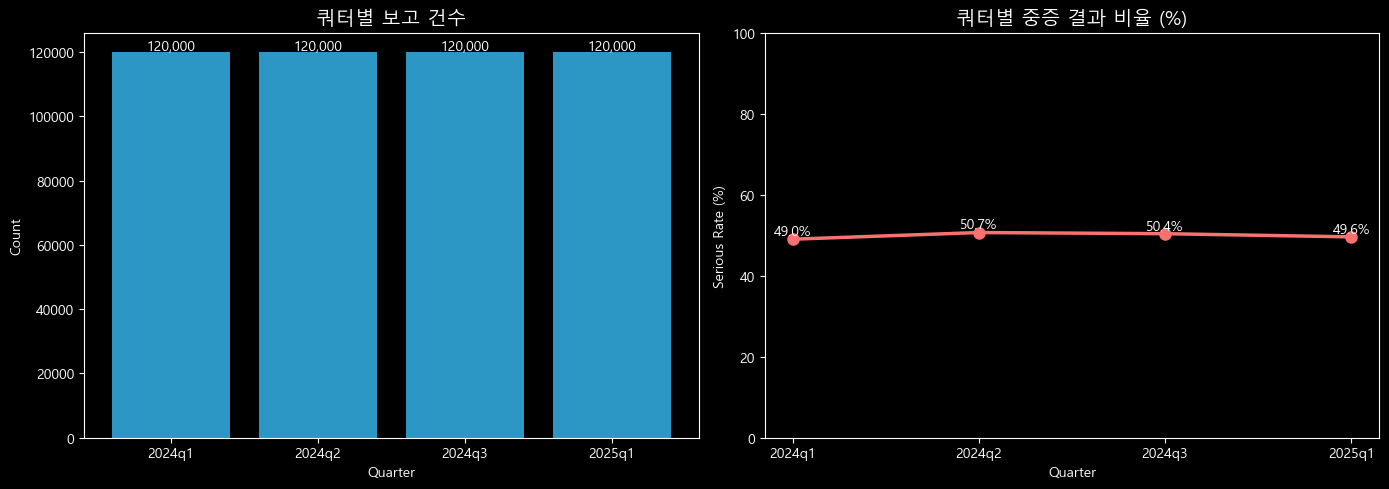

저장완료: quarter_trend.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 쿼터별 보고 건수
quarter_counts = df.groupby('quarter').size()
axes[0].bar(quarter_counts.index, quarter_counts.values, color='#38bdf8', alpha=0.8)
axes[0].set_title('쿼터별 보고 건수', fontsize=14)
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Count')
for i, v in enumerate(quarter_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# 쿼터별 중증 결과 비율
serious = {'DE', 'HO', 'LT'}
df['is_serious'] = df['outc_cod'].isin(serious)
serious_rate = df.groupby('quarter')['is_serious'].mean() * 100
axes[1].plot(serious_rate.index, serious_rate.values, 'o-', color='#f87171', linewidth=2.5, markersize=8)
axes[1].set_title('쿼터별 중증 결과 비율 (%)', fontsize=14)
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Serious Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(serious_rate.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../notebooks/quarter_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장완료: quarter_trend.png')

## 3. 위험 약물 Top 20

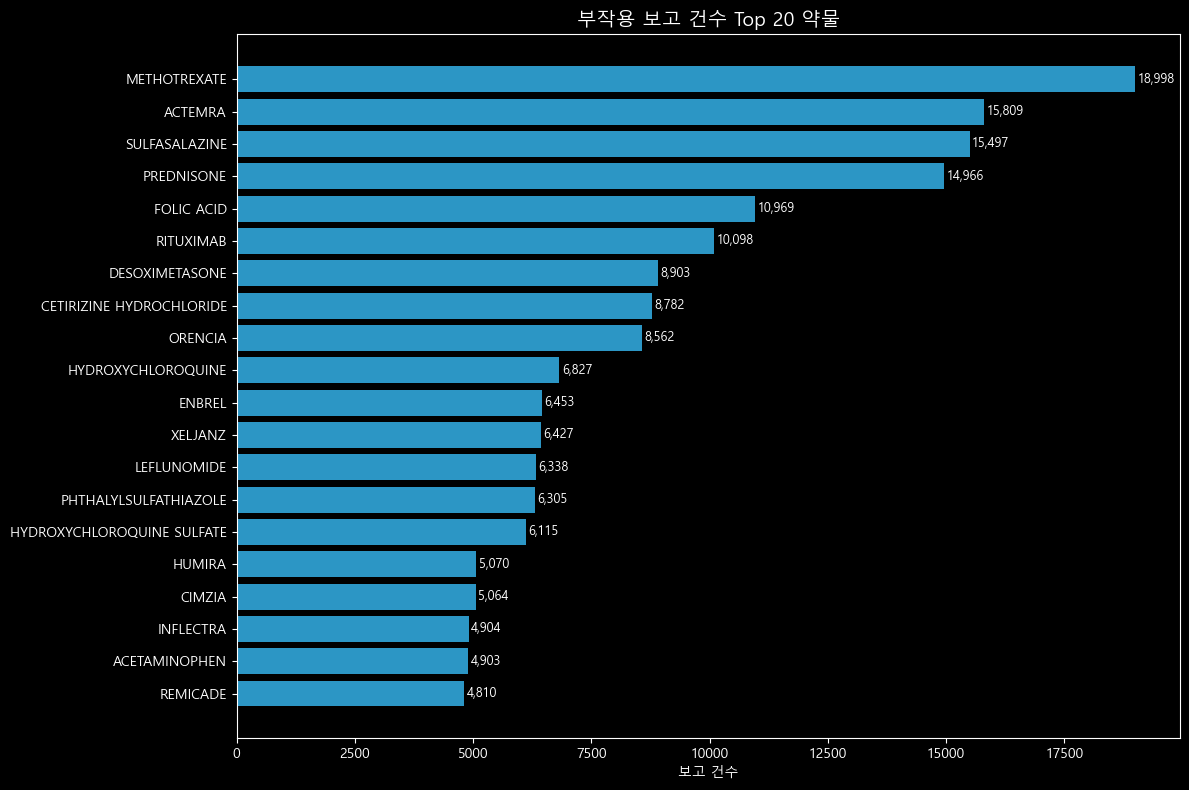

저장완료: top_drugs.png


In [4]:
# 보고 건수 기준 Top 20
top_drugs = df['drugname'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_drugs.index[::-1], top_drugs.values[::-1], color='#38bdf8', alpha=0.8)
ax.set_title('부작용 보고 건수 Top 20 약물', fontsize=14)
ax.set_xlabel('보고 건수')
for bar, val in zip(bars, top_drugs.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/top_drugs.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장완료: top_drugs.png')

## 4. 주요 부작용 Top 20

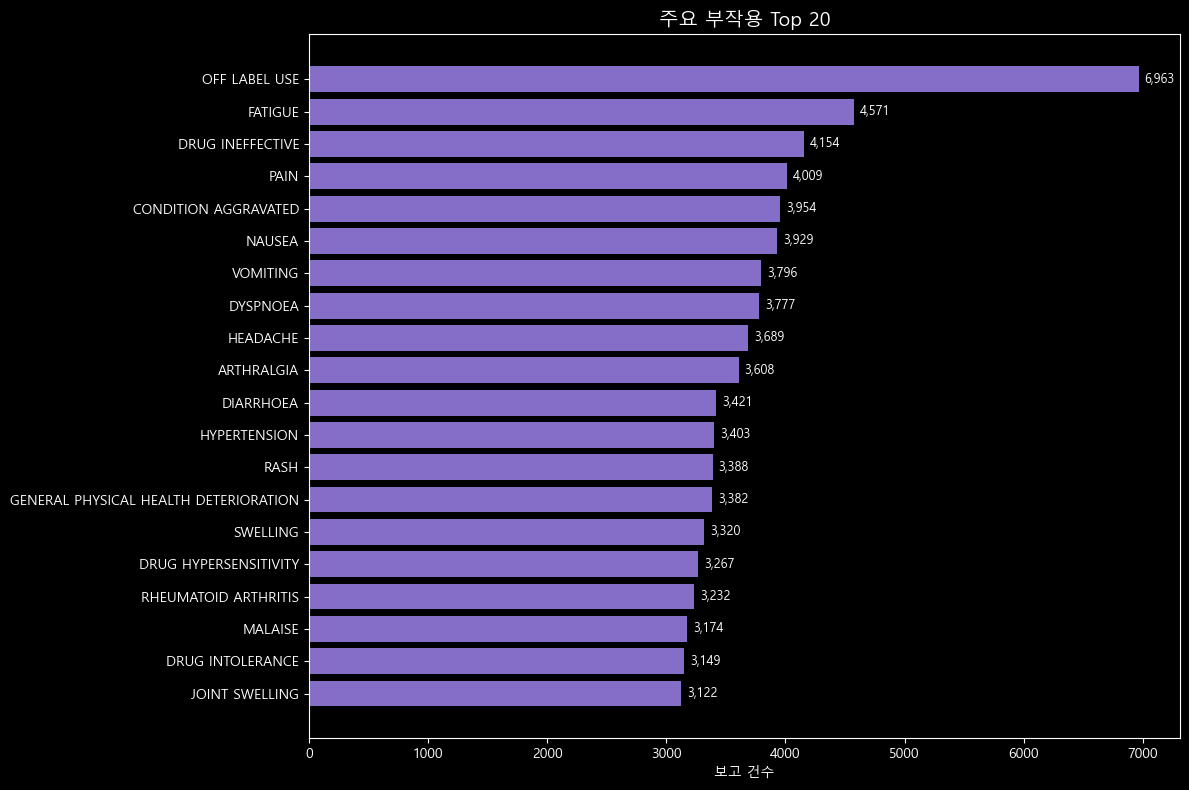

저장완료: top_reactions.png


In [5]:
top_reactions = df['pt'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_reactions.index[::-1], top_reactions.values[::-1], color='#a78bfa', alpha=0.8)
ax.set_title('주요 부작용 Top 20', fontsize=14)
ax.set_xlabel('보고 건수')
for bar, val in zip(bars, top_reactions.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/top_reactions.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장완료: top_reactions.png')

## 5. 연령/성별 분포

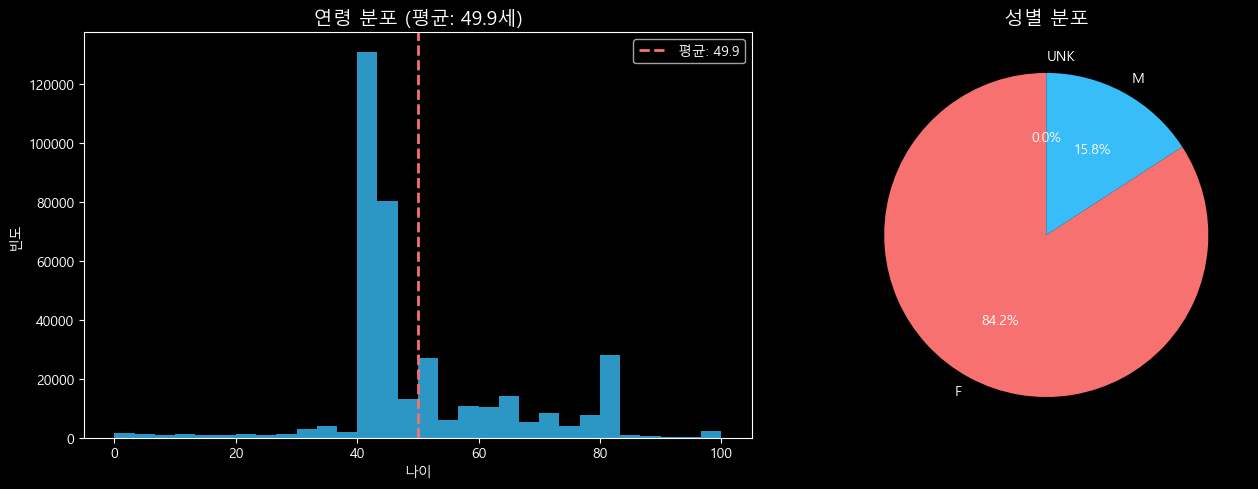

저장완료: age_sex_dist.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 연령 분포
age_data = df['age'].dropna()
axes[0].hist(age_data, bins=30, color='#38bdf8', alpha=0.8, edgecolor='none')
axes[0].set_title(f'연령 분포 (평균: {age_data.mean():.1f}세)', fontsize=14)
axes[0].set_xlabel('나이')
axes[0].set_ylabel('빈도')
axes[0].axvline(age_data.mean(), color='#f87171', linestyle='--', linewidth=2, label=f'평균: {age_data.mean():.1f}')
axes[0].legend()

# 성별 분포
sex_counts = df['sex'].value_counts()
colors = ['#f87171', '#38bdf8', '#94a3b8']
axes[1].pie(sex_counts.values, labels=sex_counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('성별 분포', fontsize=14)

plt.tight_layout()
plt.savefig('../notebooks/age_sex_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장완료: age_sex_dist.png')

## 6. 결과 코드 분포

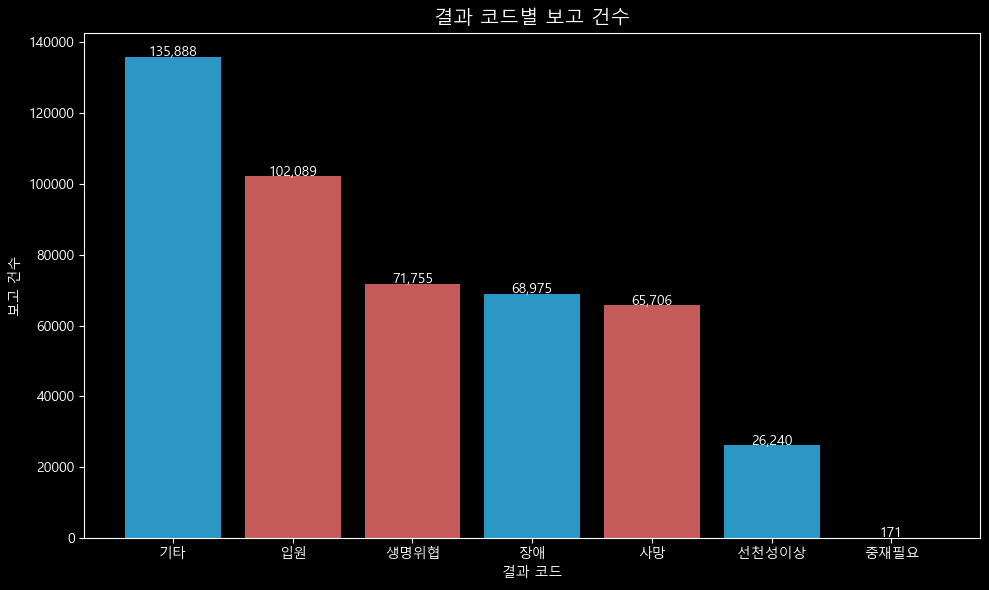

저장완료: outcome_dist.png

중증 결과(사망+입원+생명위협) 총 239,550건 (49.9%)


In [7]:
outc_map = {
    'DE': '사망', 'LT': '생명위협', 'HO': '입원',
    'DS': '장애', 'CA': '선천성이상', 'OT': '기타', 'RI': '중재필요'
}
outc_counts = df['outc_cod'].map(outc_map).value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#f87171' if k in ['사망', '생명위협', '입원'] else '#38bdf8' for k in outc_counts.index]
bars = ax.bar(outc_counts.index, outc_counts.values, color=colors_bar, alpha=0.8)
ax.set_title('결과 코드별 보고 건수', fontsize=14)
ax.set_xlabel('결과 코드')
ax.set_ylabel('보고 건수')
for bar, val in zip(bars, outc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../notebooks/outcome_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장완료: outcome_dist.png')

serious_total = df['outc_cod'].isin({'DE', 'HO', 'LT'}).sum()
print(f'\n중증 결과(사망+입원+생명위협) 총 {serious_total:,}건 ({serious_total/len(df)*100:.1f}%)')

## 7. 인사이트 요약

In [8]:
print('=' * 50)
print('📊 FDA FAERS 멀티쿼터 EDA 인사이트 요약')
print('=' * 50)
print(f'\n📌 데이터 규모')
print(f'  - 총 {len(df):,}건 (2024 Q1 ~ 2025 Q1)')
print(f'  - 고유 약물: {df["drugname"].nunique():,}종')
print(f'  - 고유 부작용: {df["pt"].nunique():,}종')

print(f'\n📌 쿼터별 트렌드')
for q, cnt in df.groupby('quarter').size().items():
    rate = df[df['quarter']==q]['outc_cod'].isin({'DE','HO','LT'}).mean()*100
    print(f'  - {q}: {cnt:,}건 (중증 {rate:.1f}%)')

print(f'\n📌 Top 5 약물')
for drug, cnt in df['drugname'].value_counts().head(5).items():
    print(f'  - {drug}: {cnt:,}건')

print(f'\n📌 Top 5 부작용')
for reac, cnt in df['pt'].value_counts().head(5).items():
    print(f'  - {reac}: {cnt:,}건')

print(f'\n📌 연령 통계')
print(f'  - 평균: {df["age"].mean():.1f}세')
print(f'  - 중앙값: {df["age"].median():.1f}세')
print(f'  - 범위: {df["age"].min():.0f}~{df["age"].max():.0f}세')

📊 FDA FAERS 멀티쿼터 EDA 인사이트 요약

📌 데이터 규모
  - 총 480,000건 (2024 Q1 ~ 2025 Q1)
  - 고유 약물: 7,076종
  - 고유 부작용: 5,799종

📌 쿼터별 트렌드
  - 2024q1: 120,000건 (중증 49.0%)
  - 2024q2: 120,000건 (중증 50.7%)
  - 2024q3: 120,000건 (중증 50.4%)
  - 2025q1: 120,000건 (중증 49.6%)

📌 Top 5 약물
  - METHOTREXATE: 18,998건
  - ACTEMRA: 15,809건
  - SULFASALAZINE: 15,497건
  - PREDNISONE: 14,966건
  - FOLIC ACID: 10,969건

📌 Top 5 부작용
  - OFF LABEL USE: 6,963건
  - FATIGUE: 4,571건
  - DRUG INEFFECTIVE: 4,154건
  - PAIN: 4,009건
  - CONDITION AGGRAVATED: 3,954건

📌 연령 통계
  - 평균: 49.9세
  - 중앙값: 44.0세
  - 범위: 0~100세
